In [13]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.inspection import permutation_importance

In [25]:
'''
This function cleans the raw dataframe created from the file on disk
    - It drops columns that do not provide a signal
    - there are some inf values in some columns
    - converts the Label (target) column to binary (0 for BENIGN) 
'''

def clean_data(data_df):

    drop = ['Source IP', 
                  'Destination IP', 
                  'SimillarHTTP', 
                  'Flow ID', 
                  'Timestamp', 
                  'Unnamed: 0']
    
    data_df.drop(drop, 
             axis=1, 
             inplace=True)
    
    # there are some inf values that we will impute with the max
    # values for that column
    data_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in ['Flow Bytes/s', 'Flow Packets/s']:
        max_val = data_df[col].max()
        data_df[col] = data_df[col].fillna(max_val)

    # change label to int (0 or 1) from object (0 if BENIGN)
    data_df['Label'] = data_df['Label'].map(lambda x: 0 if x=='BENIGN' else 1)

In [26]:
'''
This function trains each estimator in the list of estimators
on the training data provided
'''

def train_estimators(estimators,
                    X_train, 
                    y_train):
    for i, estimator in enumerate(estimators):
        estimator.fit(X_train, y_train)        

In [56]:
def train_grid(estimators,
               params,
               X_train,
               y_train):
    grids = []
    for i, estimator in enumerate(estimators):
        grid = GridSearchCV(estimator, param_grid=params[i], cv=5)
        grid.fit(X_train, y_train)
        grids.append(grid)

    return grids

In [27]:
'''
This function scores the trainied estimators on the test data
provided
returns lists of 
    - accuracy scores
    - roc/auc scores
    - precision scores
    - recall scores
'''

def score_estimators(trained_estimators,
                     X_test,
                     y_test):
    scores = []
    roc_auc_scores = []
    precision_scores = []
    recall_scores = []

    for i, estimator in enumerate(trained_estimators):
        scores.append(estimator.score(X_test, y_test))
        preds = estimator.predict(X_test)
        roc_auc_scores.append(roc_auc_score(y_test, preds))
        precision_scores.append(precision_score(y_test, preds))
        recall_scores.append(recall_score(y_test, preds))
        
    return scores, roc_auc_scores, precision_scores, recall_scores
    

In [99]:
'''
This function visualizes metrics given the trained estimaters
It displays for each estimator
    - Confusion Matrices
    - Roc Curve
    - Precision/Recall curve
'''

def display_metrics(trained_estimators, 
                    estimator_names, 
                    X_test, 
                    y_test):

    # display confusion matrices for each of the estimators
    fig, axes = plt.subplots((len(trained_estimators)//3) + 1, 3, figsize=(10,6))
    fig.suptitle('Confusion matrix comparision for different estimators')
    for i, estimator in enumerate(trained_estimators):
        row, col = i//3, i%3
        ConfusionMatrixDisplay.from_estimator(estimator,
                                              X_test,
                                              y_test,
                                              ax=axes[row, col])
        axes[row, col].set_title(estimator_names[i])
        
    for i in range(len(trained_estimators), (1 + (len(trained_estimators)//3)) * 3):
        axes[i//3, i%3].axis('off')

    plt.tight_layout()
    plt.show()

    # display Roc Curves and Precision Recall curves
    fig, axes = plt.subplots(1, 2, figsize=(10,6))
    for i, estimator in enumerate(trained_estimators):
        RocCurveDisplay.from_estimator(estimator,
                                       X_test,
                                       y_test,
                                       name=estimator_names[i],
                                       ax=axes[0])
        axes[0].set_title('ROC-AUC')
        
        PrecisionRecallDisplay.from_estimator(estimator,
                                              X_test,
                                              y_test,
                                              name=estimator_names[i],
                                              ax=axes[1])
        axes[1].set_title('Precision Recall')
        
    plt.tight_layout()
    plt.show()
        
    

In [29]:
'''
This function displays feature importance for each trained estimator
'''

def display_feature_importance(trained_estimators, 
                               X_test, 
                               y_test, 
                               estimator_names,
                               feature_names):

    for i, estimator in enumerate(trained_estimators):
        print(f'Estimator: {estimator_names[i]}:')
        print()
        
        r = permutation_importance(estimator, 
                                   X_test, 
                                   y_test,
                                   n_repeats=30,
                                   random_state=0)
        
        for i in r.importances_mean.argsort()[::-1]:
            if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
                print(f"{feature_names[i]:<30}"
                      f"{r.importances_mean[i]:.7f}"
                      f" +/- {r.importances_std[i]:.7f}")
        print()

In [30]:
'''
This function creates a dataframe given various scores
'''

def create_scores_df(estimator_names,
                     scores,
                     roc_auc_scores,
                     precision_scores,
                     recall_scores):
    scores_df = pd.DataFrame({'estimator': estimator_names,
                          'accuracy': scores,
                          'roc_auc': roc_auc_scores,
                          'precision': precision_scores,
                          'recall': recall_scores}).set_index('estimator')
    scores_df = scores_df.sort_values(by='accuracy', ascending=False)
    return scores_df

In [31]:
'''
This function plots the scores to compare the scores
for different estimators
'''

def display_scores(df):
    for column in df.columns:
        plt.plot(df.index, df[column], '-o')    
    plt.legend(df.columns)
    plt.ylim(min(df.min()), 1)
    plt.xticks(rotation=45)
    plt.ylabel('score (zoomed in)')
    plt.title('scores for classifiers')
    plt.tight_layout()
    plt.show()

In [105]:
'''
This function visualizes the results given dataframe and trained estimators 
'''

def visualize_results_df(test_df, 
                         trained_estimators, 
                         X_test_data=None, 
                         y_test_data=None,
                         protocol='All protocols'):

    print(f'************************ Results for protocol: {protocol} *******************************')
    print()
    
    if X_test_data is None:
        X_test_data, y_test_data = test_df.drop('Label', axis=1), test_df['Label']
        
    test_accuracy, test_auc_roc, test_precision, test_recall = score_estimators(trained_estimators,
                                                                                 X_test_data,
                                                                                 y_test_data)
    display_metrics(trained_estimators, estimator_names, X_test_data, y_test_data)
    test_scores_df = create_scores_df(estimator_names,
                                      test_accuracy,
                                      test_auc_roc,
                                      test_precision,
                                      test_recall)

    print()
    print()
    print("Accuracy score comparison for different estimators")
    print("--------------------------------------------------")
    print()
    
    display(test_scores_df)
    display_scores(test_scores_df)

In [74]:
'''
This function loads the data from various protocol data files. The methodology
followed is to collect the 'BENIGN' rows which indicate normal user activity
(not attack flows) from each of the protocol files and aggregate them to be
used for training and validation. This is done beacuse the number of BENIGN rows
are very small compared to the attack rows

'files' parameter is the list of file prefixes that indicate the protocol data
files
'nrows' indicate the number of rows to load from each file. By default all rows
in the file are read
'''

def load_data(files, nrows=None):

    data_files_df = pd.DataFrame()
    benign_df = pd.read_csv('data/CICDDos2019/sampled_data/aggreggated_benign.csv', low_memory=False)
    for file in files:        
        data_files_df = pd.concat([
            data_files_df, 
            pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file}.csv', 
                        low_memory=False,
                        nrows=nrows)
        ])

    # remove the benign rows from individual protocol files
    data_files_df = data_files_df.loc[data_files_df['Label'] != 'BENIGN']

    # add all benign rows
    data_files_df = pd.concat([data_files_df, benign_df])
    
    # shuffle the data
    data_files_df = data_files_df.sample(frac=1, random_state=42)
    clean_data(data_files_df)
    return data_files_df
    

In [73]:
'''
This method visualizes the results in the form of confusion-matrix, roc-auc, 
precision, recall curves. It also displays a dataframe indicating the accuracy
and other metrics

'testfile' is the file to be used as test data
'trained_estimators' is the list of estimators already trained
'''
def visualize_results(testfile, trained_estimators):
    visualize_results_df(load_data([testfile]), trained_estimators)

In [75]:
def visualize_results_test(estimators):
    test_files = [
                 'DrDoS_DNS_2',
                 'DrDoS_LDAP_1',
                 'DrDoS_MSSQL_2',
                 'DrDoS_NetBIOS_1',
                 'DrDoS_NTP_2',
                 'DrDoS_SNMP_1',
                 'DrDoS_SSDP_2',
                 'DrDoS_UDP_1',
                 'Syn_2',
                 'TFTP_1',
                 'UDPLag_2'
                ]
    test_df = load_data(test_files).drop(drop_columns, axis=1)
    print('loaded test files')
    visualize_results_df(test_df, estimators)

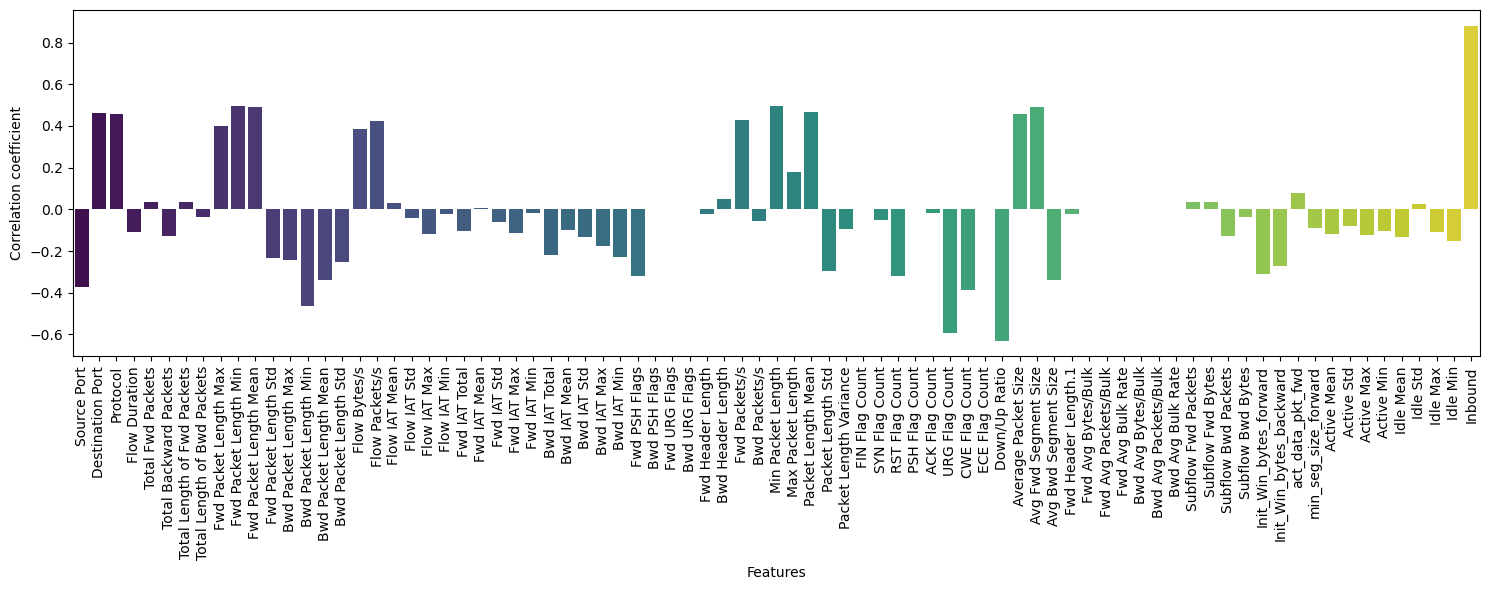

In [40]:
# visualize correlation of featuers with target
corr_matrix = data_df.corr()
corr_no_label = corr_matrix['Label'].drop('Label')

plt.figure(figsize=(15,6))
sns.barplot(x=corr_no_label.index, y=corr_no_label, hue=corr_no_label.index, palette='viridis', legend=False)
plt.ylabel('Correlation coefficient')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [76]:
drop_columns = ['Inbound', 'Down/Up Ratio', 'URG Flag Count']

In [77]:
files = [
         'DrDoS_DNS_1',
         'DrDoS_LDAP_2',
         'DrDoS_MSSQL_1',
         'DrDoS_NetBIOS_2',
         'DrDoS_NTP_1',
         'DrDoS_SNMP_2',
         'DrDoS_SSDP_1',
         'DrDoS_UDP_2',
         'Syn_1',
         'TFTP_2',
         'UDPLag_1'
        ]

data_df = load_data(files, nrows=15_000).drop(drop_columns, axis=1)

In [78]:
X, y = data_df.drop(['Label'], axis=1), data_df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((166397, 78), (166397,), (55466, 78), (55466,))

In [79]:
data_df['Label'].value_counts(normalize=True)

Label
1    0.743702
0    0.256298
Name: proportion, dtype: float64

In [109]:
estimators = [Pipeline([('sclaler', StandardScaler()),
                       ('lgr', LogisticRegression(random_state=42, max_iter=500))]),
              BaggingClassifier(random_state=42),
              RandomForestClassifier(random_state=42),
              AdaBoostClassifier(random_state=42),
              GradientBoostingClassifier(random_state=42)]

estimator_names = ['LogisticRegression',
                   'BaggingClassifier',
                   'RandomForestClassifier',
                   'AdaBoostClassifier',
                   'GrandientBoostingClassifier']

grid_params = [
               {'lgr__penalty': ['l2'], 'lgr__C': [0.01, 0.1, 1, 10]},
               {'n_estimators': [5, 10, 15], 'max_samples': [0.4, 0.7, 1.0]},
               {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 100]},
               {'n_estimators': [25, 50, 75], 'learning_rate': [0.6, 0.8, 1.0]},
               {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.5]}
              ]

In [110]:
start_time = time.time()
grids = train_grid(estimators, grid_params, X_train, y_train)
end_time = time.time()
print(f'time taken to train = {end_time-start_time}')

time taken to train = 2339.161695957184


In [111]:
for grid in grids:
    print(grid.best_params_)
    print(grid.best_estimator_)
    print(grid.best_score_)
    #print(grid.cv_results_)
    print()

{'lgr__C': 0.1, 'lgr__penalty': 'l2'}
Pipeline(steps=[('sclaler', StandardScaler()),
                ('lgr',
                 LogisticRegression(C=0.1, max_iter=500, random_state=42))])
0.9957631460313966

{'max_samples': 1.0, 'n_estimators': 15}
BaggingClassifier(n_estimators=15, random_state=42)
0.9998377374952904

{'max_depth': 100, 'n_estimators': 100}
RandomForestClassifier(max_depth=100, random_state=42)
0.9998497570872253

{'learning_rate': 1.0, 'n_estimators': 75}
AdaBoostClassifier(n_estimators=75, random_state=42)
0.9989122386677785

{'learning_rate': 0.5, 'n_estimators': 50}
GradientBoostingClassifier(learning_rate=0.5, n_estimators=50, random_state=42)
0.9998497567260596



************************ Results for protocol: All protocols *******************************



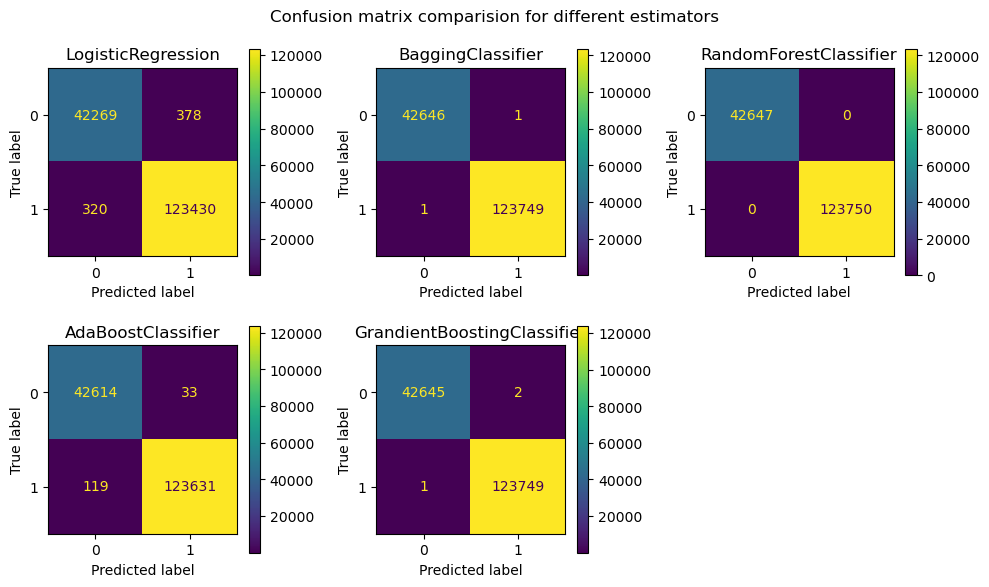

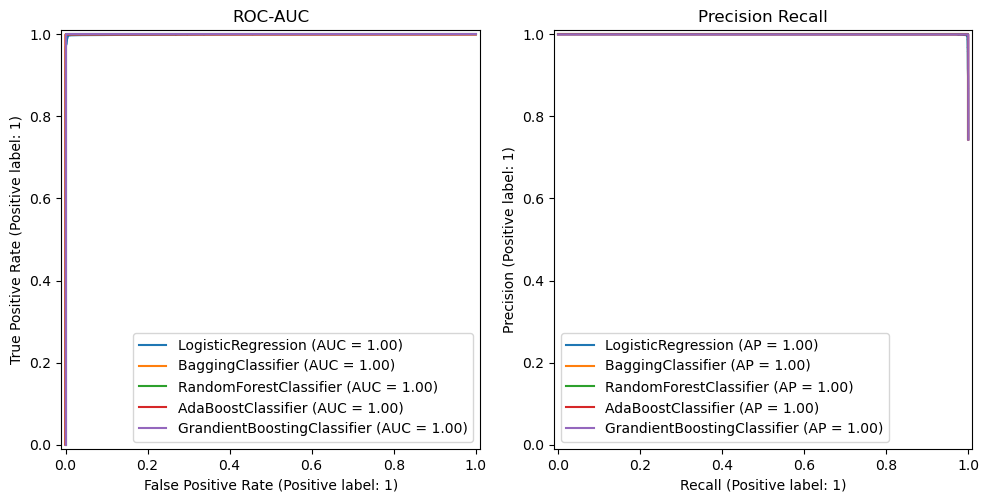



Accuracy score comparison for different estimators
--------------------------------------------------



,accuracy,roc_auc,precision,recall
estimator,,,,
RandomForestClassifier,1.000000,1.000000,1.000000,1.000000
BaggingClassifier,0.999988,0.999984,0.999992,0.999992
GrandientBoostingClassifier,0.999982,0.999973,0.999984,0.999992
AdaBoostClassifier,0.999087,0.999132,0.999733,0.999038
LogisticRegression,0.995805,0.994275,0.996947,0.997414


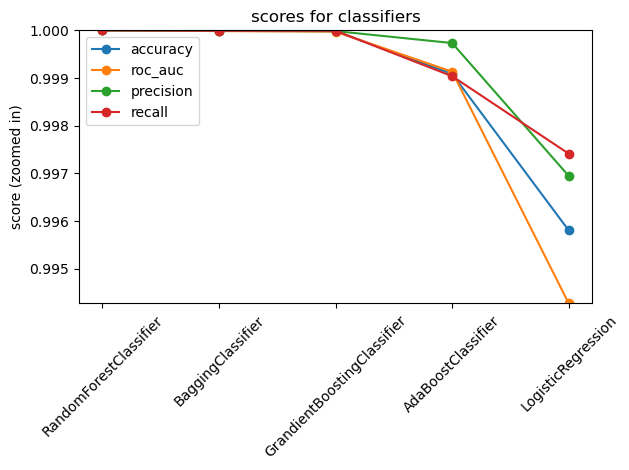

In [112]:
visualize_results_df(data_df, grids, X_train, y_train)

loaded test files
************************ Results for protocol: All protocols *******************************



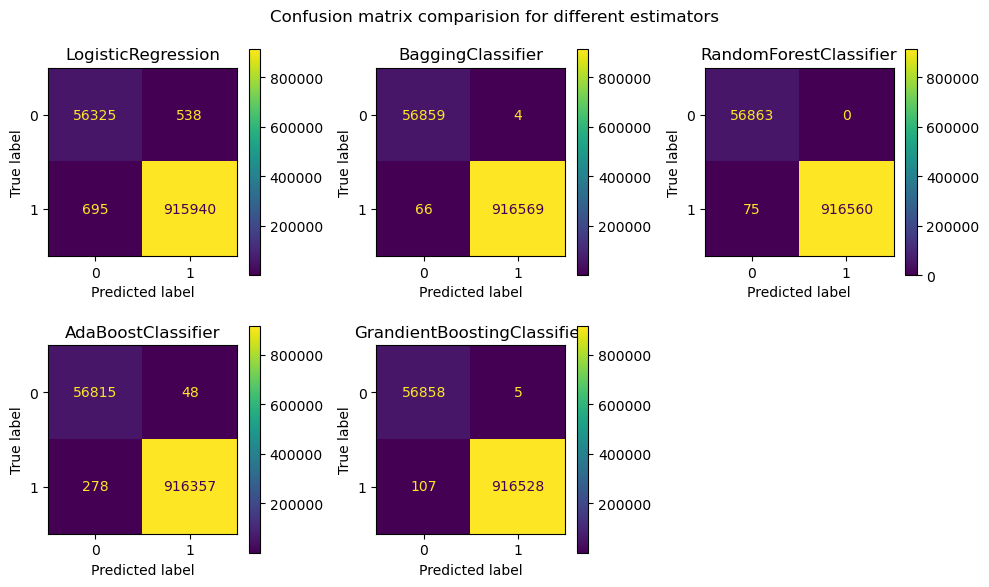

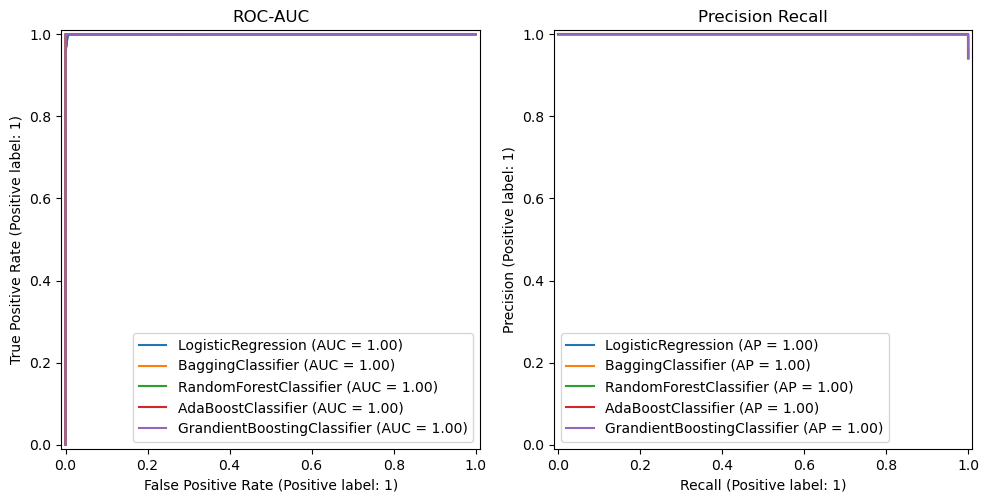



Accuracy score comparison for different estimators
--------------------------------------------------



,accuracy,roc_auc,precision,recall
estimator,,,,
BaggingClassifier,0.999928,0.999929,0.999996,0.999928
RandomForestClassifier,0.999923,0.999959,1.000000,0.999918
GrandientBoostingClassifier,0.999885,0.999898,0.999995,0.999883
AdaBoostClassifier,0.999665,0.999426,0.999948,0.999697
LogisticRegression,0.998733,0.994890,0.999413,0.999242


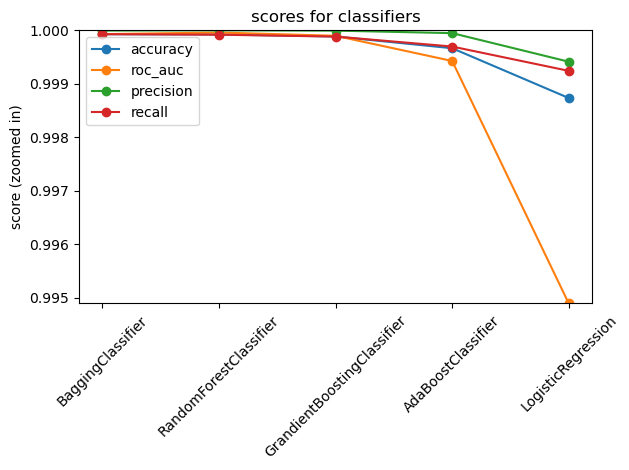

In [113]:
visualize_results_test(grids)

In [114]:
start_time = time.time()
display_feature_importance(grids, 
                           X_test, 
                           y_test, 
                           estimator_names,
                           X.columns)
end_time = time.time()
print(f'time = {end_time-start_time}')

Estimator: LogisticRegression:

ACK Flag Count                0.1269955 +/- 0.0006291
Packet Length Mean            0.0336470 +/- 0.0007205
Protocol                      0.0334006 +/- 0.0004130
Average Packet Size           0.0220315 +/- 0.0006133
Fwd Packet Length Mean        0.0217605 +/- 0.0005961
Avg Fwd Segment Size          0.0217605 +/- 0.0005961
Min Packet Length             0.0187346 +/- 0.0005908
Init_Win_bytes_backward       0.0126744 +/- 0.0002982
Bwd Packet Length Min         0.0109100 +/- 0.0004105
Fwd Packet Length Std         0.0065253 +/- 0.0002285
Fwd Packet Length Min         0.0060025 +/- 0.0002822
Bwd IAT Total                 0.0052585 +/- 0.0002219
Bwd Packet Length Max         0.0051203 +/- 0.0001873
Active Mean                   0.0027807 +/- 0.0000989
Init_Win_bytes_forward        0.0024526 +/- 0.0001554
Packet Length Variance        0.0019021 +/- 0.0001494
Bwd Packet Length Std         0.0013498 +/- 0.0001346
Fwd IAT Mean                  0.0011088 +/- 0.0001

In [ ]:
def get_protocol_df(file_prefix):
    data1_df = pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file_prefix}_1.csv', low_memory=False)
    data2_df = pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file_prefix}_2.csv', low_memory=False)
    data3_df = pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file_prefix}_3.csv', low_memory=False)
    data_df = pd.concat([data1_df, data2_df, data3_df])
    clean_data(data_df)
    #shuffle the sample
    return data_df.sample(frac=1, random_state=42)

In [ ]:
def visualize_results_protocols(estimators):
    files_prefix = [
         'DrDoS_DNS',
         'DrDoS_LDAP',
         'DrDoS_MSSQL',
         'DrDoS_NetBIOS',
         'DrDoS_NTP',
         'DrDoS_SNMP',
         'DrDoS_SSDP',
         'DrDoS_UDP',
         'Syn',
         'TFTP',
         'UDPLag'
        ]
    
    for file_prefix in files_prefix:
        prot_df = get_protocol_df(file_prefix)
        visualize_results_df(prot_df, estimators, protocol=file_prefix)